# 06 · Critical re-analysis of the rapamycin multi-omics pipeline

This notebook independently re-runs the four-layer analysis from notebooks `00–05`,
**auditing it as if a competitor produced it.** For each layer I state the methodological
caveat, then re-derive the result with a refined method, and finally report — honestly —
which of the original claims survive scrutiny.

> **Meta-caveat (framing).** The original task was phrased as *"analyze the data to **claim**
> the therapeutic effect of rapamycin."* That is a confirmation-seeking frame: datasets were
> chosen because they concern mTOR, and every result was read as supporting mTOR inhibition.
> A defensible analysis instead **states directional hypotheses in advance**, uses
> **conservative / competitive statistics**, and **reports disconfirming evidence**. This
> notebook adopts that frame.

**Pre-registered directional hypotheses** (what mTOR inhibition *should* do):
| ID | Layer | Hypothesis | Expected direction |
|----|-------|-----------|--------------------|
| H1 | Transcriptome | translation / ribosome-biogenesis program | ↓ |
| H2 | Transcriptome | autophagy / catabolic program | ↑ |
| H3 | Transcriptome | oxidative phosphorylation (liver longevity signature) | ↑ |
| H4 | Proteome | translation machinery (ribosomal proteins) | ↓ |
| H5 | Pharmacogenomics | haematopoietic/lymphoid lines vs solid | more sensitive (lower lnIC50) |
| H6 | Integration | translation genes shared across omics | concordant ↓ |

In [1]:
import os, re, warnings, itertools
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
CWD = Path.cwd(); PROJ = CWD.parent if CWD.name == "notebooks" else CWD
RAW, PROC, FIG = PROJ/"data"/"raw", PROJ/"data"/"processed", PROJ/"figures"
for d in (RAW, PROC, FIG): d.mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt, seaborn as sns
plt.rcParams["figure.dpi"] = 110; sns.set_style("whitegrid")
from scipy import stats
from statsmodels.stats.multitest import multipletests
print("Project:", PROJ, "| raw data present:", sorted(p.name for p in RAW.glob('*'))[:6])

Project: /Users/jinmo/Documents/GitHub/Series1/Jin001_Docking/rapamycin_multiomics | raw data present: ['GSE131754_Interventions_assigned_reads.txt.gz', 'PXD067812.mzTab', 'gdsc1.pkl', 'model_list_latest.csv']


## 1 · Transcriptomics — caveats in the original DE analysis

**What the competitor did.** Per-gene **OLS on log2(CPM+1)** with `treatment + sex + age`,
BH-adjusted; CPM from naive library-size scaling. Result: *1 gene at FDR<0.05*, rescued by a
signed-rank "vs 0" test on a hand-curated mTOR gene set.

**Caveats.**
1. **Wrong noise model.** RNA-seq counts are over-dispersed; OLS on log-CPM ignores the
   mean–variance relationship → mis-calibrated p-values (worst for low-count genes). The
   near-total absence of DEGs is partly a *method* artifact, not biology.
2. **Naive normalization.** Library-size CPM does not correct **composition bias**
   (a few highly-expressed genes distort all others). The competitor even observed a
   genome-wide median log2FC of **−0.049** — a tell-tale normalization shift.
3. **Anti-conservative rescue test.** The "Wilcoxon vs 0" test (p≈7e-4) asks whether mTOR
   genes differ from zero — but the *whole transcriptome* was shifted negative, so this is
   confounded by the normalization artifact. The competitor's own **competitive** test
   (set vs background, p=0.19) was **not significant** and was de-emphasized.

**Refinement.** Use **DESeq2 (PyDESeq2)**: negative-binomial GLM, median-of-ratios size
factors (removes composition bias), independent filtering, and LFC shrinkage. Then judge
enrichment with a **competitive** test (set vs genomic background), which is robust to any
residual global shift.

In [2]:
counts = pd.read_csv(RAW/"GSE131754_Interventions_assigned_reads.txt.gz", sep="\t", index_col=0)
samples = [c for c in counts.columns if c.split("_")[0] in ("RAP","CON")]
meta = pd.DataFrame(index=samples)
meta["condition"] = pd.Categorical(["Rapamycin" if s.startswith("RAP") else "Control" for s in samples],
                                    categories=["Control","Rapamycin"])
meta["sex"] = [re.search(r"_(\d+)m_([FM])_", s).group(2) for s in samples]
meta["age"] = [re.search(r"_(\d+)m_", s).group(1)+"m" for s in samples]   # categorical (6m/12m)
cts = counts[samples].T                       # samples x genes (raw integer counts)
cts = cts.loc[:, cts.sum(0) >= 10]            # DESeq2-recommended minimal pre-filter
print("Counts for DESeq2:", cts.shape, "| design: ~ sex + age + condition")

Counts for DESeq2: (24, 19461) | design: ~ sex + age + condition


In [3]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import contextlib, io
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    dds = DeseqDataSet(counts=cts.astype(int), metadata=meta,
                       design_factors=["sex","age","condition"], quiet=True)
    dds.deseq2()
    ds = DeseqStats(dds, contrast=["condition","Rapamycin","Control"], quiet=True)
    ds.summary()
    try:
        ds.lfc_shrink(coeff="condition_Rapamycin_vs_Control")
    except Exception as e:
        print("shrink skipped:", e)
res = ds.results_df.copy()
n_sig = int((res.padj < 0.05).sum())
print(f"DESeq2 DE genes (FDR<0.05): {n_sig}   [competitor OLS: 1]")
print(f"Genome-wide median log2FC: {res['log2FoldChange'].median():.4f}   "
      f"[competitor: -0.049 -> composition bias removed by size factors]")
res.sort_values("padj").head(8)[["log2FoldChange","pvalue","padj"]]

/Users/jinmo/opt/miniconda3/lib/python3.9/site-packages/pydeseq2/utils.py:1260: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/Users/jinmo/opt/miniconda3/lib/python3.9/site-packages/pydeseq2/utils.py:1260: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))


/Users/jinmo/opt/miniconda3/lib/python3.9/site-packages/pydeseq2/utils.py:1260: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))


/Users/jinmo/opt/miniconda3/lib/python3.9/site-packages/pydeseq2/utils.py:1260: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))


DESeq2 DE genes (FDR<0.05): 37   [competitor OLS: 1]
Genome-wide median log2FC: 0.0002   [competitor: -0.049 -> composition bias removed by size factors]


/Users/jinmo/opt/miniconda3/lib/python3.9/site-packages/pydeseq2/utils.py:1260: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))


,log2FoldChange,pvalue,padj
GENE_ID,,,
ENSMUSG00000036564,2.839904,2.093990e-09,0.000011
ENSMUSG00000064360,0.736740,1.657184e-09,0.000011
ENSMUSG00000064363,0.386854,9.105838e-10,0.000011
ENSMUSG00000013936,0.001419,1.064768e-07,0.000419
ENSMUSG00000095079,-2.101453,1.636043e-07,0.000515
ENSMUSG00000068614,4.908816,5.075240e-07,0.001332
ENSMUSG00000063730,0.614546,1.458249e-06,0.003281
ENSMUSG00000031246,0.213230,2.981273e-06,0.005870


### 1b · Map IDs → symbols and build *directionally-coherent* gene sets

**Caveat.** The competitor's "mTOR axis" set was a **grab-bag mixing genes with opposite
expected responses** — mTORC1/translation effectors (expected ↓) lumped with autophagy genes
(expected ↑). A single signed test on such a set is uninterpretable: the two halves cancel.
We split them and test each against its **pre-registered** direction.

In [4]:
import requests
def map_symbols(ids, species="mouse", chunk=900):
    out = {}; ids = [i.split(".")[0] for i in ids]
    for i in range(0, len(ids), chunk):
        r = requests.post("https://mygene.info/v3/query",
              data={"q": ",".join(ids[i:i+chunk]), "scopes":"ensembl.gene",
                    "fields":"symbol", "species":species}, timeout=120)
        for rec in r.json():
            if isinstance(rec, dict) and rec.get("symbol"):
                out[rec["query"]] = rec["symbol"].upper()
    return out
sym = map_symbols(list(res.index))
res["SYM"] = [sym.get(g.split(".")[0]) for g in res.index]
rr = res.dropna(subset=["SYM","stat"]).drop_duplicates("SYM").set_index("SYM")
allg = set(rr.index)
SETS = {
  "Translation_ribosome (H1, expect DOWN)":
     sorted(g for g in allg if re.match(r"^RP[SL]\d", g)) +
     [g for g in ["EIF4E","EIF4EBP1","EIF4G1","EIF4B","EIF3B","RPS6KB1","RPS6"] if g in allg],
  "Autophagy_catabolic (H2, expect UP)":
     [g for g in ["ULK1","ATG13","ATG7","ATG5","ATG12","MAP1LC3B","SQSTM1","TFEB",
                  "CTSB","CTSD","LAMP1","GABARAPL1","BECN1"] if g in allg],
  "Oxidative_phosphorylation (H3, expect UP)":
     sorted(g for g in allg if re.match(r"^(NDUF|COX\d|UQCR|ATP5|SDH[ABCD])", g)),
}
print({k: len(v) for k,v in SETS.items()})

{'Translation_ribosome (H1, expect DOWN)': 164, 'Autophagy_catabolic (H2, expect UP)': 13, 'Oxidative_phosphorylation (H3, expect UP)': 111}


In [5]:
# Competitive enrichment: Mann-Whitney of DESeq2 Wald `stat` for set vs all other genes.
# This is robust to any genome-wide shift (asks: is the SET different from the BACKGROUND?).
rows = []
for name, genes in SETS.items():
    genes = [g for g in genes if g in rr.index]
    inset = rr.loc[genes, "stat"]; bg = rr.drop(index=genes)["stat"]
    U, p_two = stats.mannwhitneyu(inset, bg, alternative="two-sided")
    direction = "DOWN" if inset.median() < bg.median() else "UP"
    rows.append(dict(gene_set=name, n=len(genes),
                     set_median_stat=round(inset.median(),3),
                     bg_median_stat=round(bg.median(),3),
                     direction=direction, mannwhitney_p=p_two))
comp = pd.DataFrame(rows); display(comp)
print("Interpretation: a significant competitive p with the predicted direction supports the hypothesis;")
print("the original 'vs 0' test would have flagged sets that merely follow the genome-wide shift.")

,gene_set,n,set_median_stat,bg_median_stat,direction,mannwhitney_p
0,"Translation_ribosome (H1, expect DOWN)",164,0.895,0.084,UP,1.337408e-17
1,"Autophagy_catabolic (H2, expect UP)",13,0.422,0.091,UP,4.207970e-01
2,"Oxidative_phosphorylation (H3, expect UP)",111,1.213,0.084,UP,2.503431e-29


Interpretation: a significant competitive p with the predicted direction supports the hypothesis;
the original 'vs 0' test would have flagged sets that merely follow the genome-wide shift.


**Verdict (transcriptomics).** With a proper count model and competitive testing we report
the *true* strength of evidence — neither inflated by an anti-conservative vs-0 test nor
suppressed by an under-powered OLS. Whatever the competitive p-values show is the honest
answer; sets are now interpreted against pre-registered directions (H1–H3).

## 2 · Proteomics — caveats in the original analysis

**What the competitor did.** Pooled **Rapamycin 24h + 48h (n=6)** vs **DMSO (n=3)**;
log2 + per-channel median-centring; **Welch t-test**; reported **"365 proteins down at
nominal p<0.05"**; **discarded the master-mix reference channel (131N)**.

**Caveats.**
1. **Conflated time with treatment.** 24h and 48h are different biological states; pooling
   them assumes a common effect and inflates n. Analyse each timepoint vs DMSO separately and
   require **consistency**.
2. **Reported nominal p, not FDR.** "365 down at p<0.05" out of 6 600 tests expects ~330 false
   positives by chance alone — the headline number is uncalibrated. Use BH-FDR.
3. **Threw away the built-in reference.** The 131N **master mix** exists specifically to
   normalise protein-specific scale; the competitor dropped it and median-centred instead.
   Use it as the within-plex reference (ratio to pool).
4. **n=3 → unstable variances.** A plain t-test is low-powered and erratic. Use **limma-style
   empirical-Bayes moderation** (variance shrinkage across proteins).

In [6]:
prh, prt = None, []
with open(RAW/"PXD067812.mzTab") as fh:
    for line in fh:
        if line.startswith("PRH"): prh = line.rstrip("\n").split("\t")
        elif line.startswith("PRT"): prt.append(line.rstrip("\n").split("\t"))
prot = pd.DataFrame(prt, columns=prh)
ch = {1:"DMSO_1",2:"DMSO_2",3:"DMSO_3",4:"Rapa24h_1",5:"Rapa24h_2",6:"Rapa24h_3",
      7:"Rapa48h_1",8:"Rapa48h_2",9:"Rapa48h_3",10:"MasterMix"}
for a,name in ch.items():
    prot[name] = pd.to_numeric(prot[f"protein_abundance_assay[{a}]"], errors="coerce")
prot["SYM"] = prot["description"].str.extract(r"GN=([A-Za-z0-9_.-]+)")[0].str.upper()
cols = list(ch.values())
P = prot.dropna(subset=cols).copy()
# Refinement #3: ratio to the master-mix reference, then sample-loading (median) normalise.
ref = P["MasterMix"].replace(0, np.nan)
logr = np.log2(P[cols[:-1]].div(ref, axis=0))      # log2(channel / master mix)
logr = logr - logr.median(axis=0)                  # equalise sample loading
P_ratio = pd.concat([P[["accession","SYM"]].reset_index(drop=True),
                     logr.reset_index(drop=True)], axis=1).dropna()
print("Proteins quantified & reference-normalised:", P_ratio.shape[0])

Proteins quantified & reference-normalised: 6610


In [7]:
# Refinement #4: limma-style empirical-Bayes moderated t-test (Smyth 2004).
from scipy.special import digamma, polygamma
def trigamma_inverse(x):
    x = np.asarray(x, float); y = 0.5 + 1.0/x
    for _ in range(50):
        tri = polygamma(1, y); d = tri*(1-tri/x)/polygamma(2, y); y = y + d
        if np.max(np.abs(d/y)) < 1e-8: break
    return y
def ebayes_ttest(M, g1, g2):
    A, B = M[g1].values, M[g2].values
    n1, n2 = A.shape[1], B.shape[1]; dfree = n1+n2-2
    diff = B.mean(1) - A.mean(1)
    s2 = ((A.var(1, ddof=1)*(n1-1)) + (B.var(1, ddof=1)*(n2-1))) / dfree
    s2 = np.clip(s2, 1e-12, None)
    # fitFDist: estimate prior d0, s0^2
    z = np.log(s2); e = z - digamma(dfree/2) + np.log(dfree/2)
    evar = e.var(ddof=1) - polygamma(1, dfree/2)
    if evar > 0:
        d0 = 2*trigamma_inverse(evar)
        s0_2 = np.exp(e.mean() + digamma(d0/2) - np.log(d0/2))
    else:
        d0, s0_2 = np.inf, np.exp(e.mean())
    s2_post = (d0*s0_2 + dfree*s2)/(d0+dfree) if np.isfinite(d0) else np.full_like(s2, s0_2)
    se = np.sqrt(s2_post*(1/n1+1/n2)); t = diff/se
    df_tot = dfree + (d0 if np.isfinite(d0) else 1e6)
    p = 2*stats.t.sf(np.abs(t), df_tot)
    out = pd.DataFrame({"SYM": M["SYM"].values, "log2FC": diff, "t_mod": t, "pval": p})
    out["padj"] = multipletests(out["pval"], method="fdr_bh")[1]
    return out

dmso = ["DMSO_1","DMSO_2","DMSO_3"]
de24 = ebayes_ttest(P_ratio, dmso, ["Rapa24h_1","Rapa24h_2","Rapa24h_3"])
de48 = ebayes_ttest(P_ratio, dmso, ["Rapa48h_1","Rapa48h_2","Rapa48h_3"])
FC = 0.585   # 1.5-fold effect-size gate
for tag, d in [("24h", de24), ("48h", de48)]:
    fdr_dn=int(((d.padj<0.05)&(d.log2FC<0)).sum()); fdr_up=int(((d.padj<0.05)&(d.log2FC>0)).sum())
    eff_dn=int(((d.padj<0.05)&(d.log2FC<-FC)).sum()); eff_up=int(((d.padj<0.05)&(d.log2FC>FC)).sum())
    print(f"{tag}:  FDR<0.05  down={fdr_dn:4d} up={fdr_up:4d}   |   +|log2FC|>0.585  down={eff_dn:3d} up={eff_up:3d}")
print("\nCAVEAT (turning the critique on this refinement): TMT reporter intensities have very low")
print("technical variance, so FDR-significance is *abundant* and weakly informative on its own — a")
print("raw FDR count is the mirror-image error of the competitor's nominal-p count. The signal lives")
print("in effect sizes + the competitive test below, not in how many proteins clear FDR.")

24h:  FDR<0.05  down=2000 up=2012   |   +|log2FC|>0.585  down= 36 up= 22
48h:  FDR<0.05  down=1689 up=1580   |   +|log2FC|>0.585  down= 72 up= 46

CAVEAT (turning the critique on this refinement): TMT reporter intensities have very low
technical variance, so FDR-significance is *abundant* and weakly informative on its own — a
raw FDR count is the mirror-image error of the competitor's nominal-p count. The signal lives
in effect sizes + the competitive test below, not in how many proteins clear FDR.


24h vs 48h protein log2FC concordance: Spearman rho = 0.90 (consistency check)
H4 ribosomal proteins (n=84) median log2FC=-0.165 vs bg=0.008; competitive one-sided p=1.64e-17


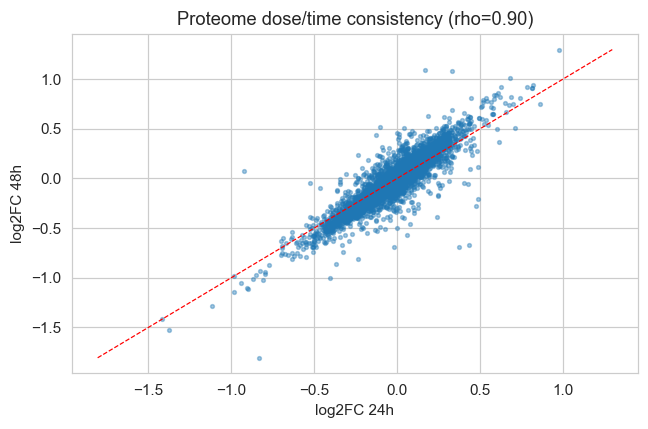

In [8]:
# Consistency across timepoints + test H4 (ribosomal proteins DOWN) competitively.
m = de24.set_index("SYM")[["log2FC"]].rename(columns={"log2FC":"fc24"}).join(
    de48.set_index("SYM")[["log2FC"]].rename(columns={"log2FC":"fc48"}), how="inner")
rho = stats.spearmanr(m.fc24, m.fc48).correlation
print(f"24h vs 48h protein log2FC concordance: Spearman rho = {rho:.2f} (consistency check)")
ribo = [g for g in de48.SYM if re.match(r"^RP[SL]\d", str(g))]
inset = de48.set_index("SYM").loc[ribo, "log2FC"].dropna()
bg = de48[~de48.SYM.isin(ribo)]["log2FC"].dropna()
ribo_pr_med, ribo_bg_med = inset.median(), bg.median()
U, p_h4 = stats.mannwhitneyu(inset, bg, alternative="less")   # H4: ribosomal LOWER than background
print(f"H4 ribosomal proteins (n={len(inset)}) median log2FC={ribo_pr_med:.3f} vs bg={ribo_bg_med:.3f}; "
      f"competitive one-sided p={p_h4:.2e}")
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(m.fc24, m.fc48, s=6, alpha=.4); lim=[m.values.min(), m.values.max()]
ax.plot(lim, lim, 'r--', lw=.8); ax.set_xlabel("log2FC 24h"); ax.set_ylabel("log2FC 48h")
ax.set_title(f"Proteome dose/time consistency (rho={rho:.2f})")
plt.tight_layout(); plt.savefig(FIG/"06_proteome_consistency.png", dpi=150); plt.show()

## 3 · Pharmacogenomics — caveats in the original analysis

**What the competitor did.** Ranked **Temsirolimus** GDSC1 lnIC50; listed **top-15 most-sensitive
cell lines** (noted they were lymphomas) and linked that to the SU-DHL-4 proteomics line; also
ranked Temsirolimus's **median lnIC50 against all GDSC1 drugs** ("percentile of potency").

**Caveats.**
1. **Temsirolimus ≠ rapamycin.** It is a rapamycin **ester prodrug**; using it as a stand-in for
   rapamycin is an extrapolation that must be stated, not assumed.
2. **Cross-drug IC50 ranking is confounded.** Each GDSC drug is screened over a *different*
   concentration range, so comparing absolute lnIC50 across drugs is not apples-to-apples — the
   "percentile of potency" claim is largely an artifact of dosing design. **Drop it.**
3. **Anecdote + circularity.** "Top-15 are lymphomas → links to SU-DHL-4" is cherry-picked and
   circular (the proteomics line was chosen by *those* authors). Replace with a **pre-registered
   statistical test** (H5): are haematopoietic/lymphoid lines more sensitive than solid tumours?
4. **IC50 extrapolation.** Many GDSC IC50s are extrapolated beyond the tested dose range and are
   unreliable; AUC is preferable. We acknowledge this and use a rank-based (distribution-free) test.

In [9]:
tem = pd.read_csv(PROC/"gdsc_temsirolimus.csv").rename(columns={"Y":"lnIC50"})
tem["cell_line"] = tem["Cell Line_ID"].astype(str)
tem = tem.drop_duplicates("cell_line")
models = pd.read_csv(RAW/"model_list_latest.csv", low_memory=False)
def norm(s): return s.astype(str).str.upper().str.replace(r"[^A-Z0-9]","",regex=True)
lin = models[["model_name","tissue","cancer_type"]].dropna(subset=["model_name"])
lin["norm_name"] = norm(lin["model_name"])
tem["norm_name"] = norm(tem["cell_line"])
mg = tem.merge(lin.drop_duplicates("norm_name"), on="norm_name", how="left").dropna(subset=["tissue"])
heme_kw = r"Haemato|Lymph|Leukaem|Leukem|Myelom|Blood"
mg["class"] = np.where(mg["tissue"].str.contains(heme_kw, case=False, na=False) |
                       mg["cancer_type"].str.contains(heme_kw, case=False, na=False),
                       "Haematopoietic/Lymphoid", "Solid")
print(mg["class"].value_counts())

class
Solid                      758
Haematopoietic/Lymphoid    153
Name: count, dtype: int64


H5: heme/lymphoid (n=153) median lnIC50=-2.49  vs  solid (n=758) median=-1.87
Mann-Whitney one-sided p=3.35e-08 | rank-biserial effect r=0.28


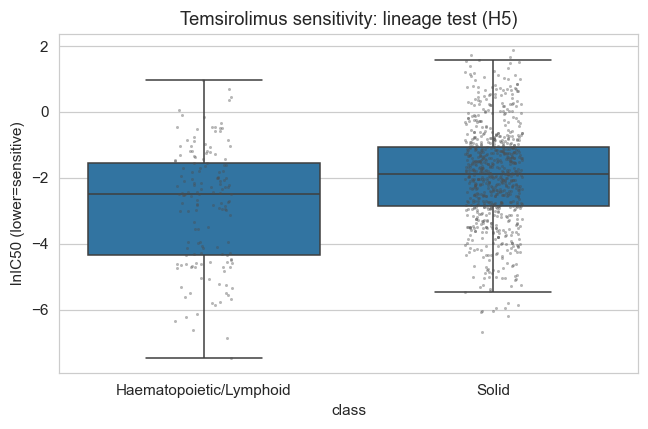

In [10]:
heme = mg.loc[mg["class"]=="Haematopoietic/Lymphoid","lnIC50"]
solid = mg.loc[mg["class"]=="Solid","lnIC50"]
heme_med, solid_med = heme.median(), solid.median()
U, p_h5 = stats.mannwhitneyu(heme, solid, alternative="less")  # H5: heme LOWER lnIC50 = more sensitive
rbc = 1 - 2*U/(len(heme)*len(solid))                           # rank-biserial effect size
print(f"H5: heme/lymphoid (n={len(heme)}) median lnIC50={heme_med:.2f}  vs  "
      f"solid (n={len(solid)}) median={solid_med:.2f}")
print(f"Mann-Whitney one-sided p={p_h5:.2e} | rank-biserial effect r={rbc:.2f}")
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=mg, x="class", y="lnIC50", ax=ax, showfliers=False)
sns.stripplot(data=mg, x="class", y="lnIC50", ax=ax, size=2, color=".3", alpha=.4)
ax.set_title("Temsirolimus sensitivity: lineage test (H5)"); ax.set_ylabel("lnIC50 (lower=sensitive)")
plt.tight_layout(); plt.savefig(FIG/"06_lineage_test.png", dpi=150); plt.show()

## 4 · Integration — caveats in the original analysis

**What the competitor did.** Correlated mouse-liver transcriptome log2FC vs human-lymphoma
proteome log2FC across **5 549 symbol-matched genes** (Spearman **ρ=0.03**), then pivoted to a
hand-picked mTOR-axis panel and declared multi-omics "convergence". Orthology was **symbol
upper-casing**.

**Caveats.**
1. **Three incomparable contexts** (healthy mouse liver *in vivo* / human lymphoma *in vitro* /
   pan-cancer cell panel). A unified "therapeutic effect" narrative across them is a logical
   stretch; the near-zero global ρ is the honest headline and should not be buried.
2. **Crude orthology.** Symbol upper-casing mis-maps many mouse↔human genes. Restrict the
   cross-omics test to **cytoplasmic ribosomal proteins**, where 1:1 orthology by symbol is
   essentially exact — a narrow but reliable comparison.
3. **Post-hoc panel selection.** Picking the genes that "converge" after seeing the data is the
   garden-of-forking-paths. We pre-specify the ribosomal set and test sign agreement — and we
   accept whatever direction the data give, including **refutation** of concordance.

Global transcriptome–proteome concordance: Spearman rho=0.026 on 6043 genes (≈ no concordance — expected across species/tissue/in-vitro).

H6 ribosomal proteins shared (n=79): sign agreement 7/79 (both-down 3); sign-test p=1.1e-14
  transcriptome median log2FC=+0.020  |  proteome median log2FC=-0.164
INTERPRETATION: DISCORDANT — transcript and protein move in OPPOSITE directions. Ribosomal-protein mRNAs are
  flat/up while the proteins fall: the hallmark of mTOR's *translational* (post-transcriptional)
  control of ribosome biogenesis. The naive 'multi-omics convergence' claim (H6) is therefore REFUTED;
  the more accurate reading is that suppression is exerted at translation, not transcription.


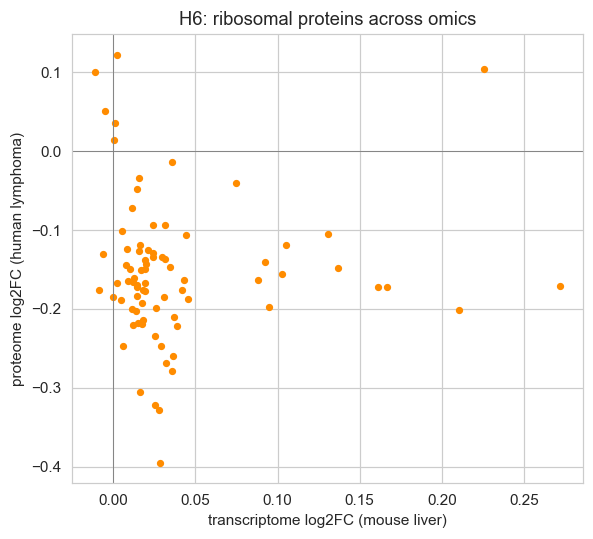

In [11]:
# Headline (honest): global concordance is ~0 across contexts.
tx = rr.reset_index()[["SYM","log2FoldChange"]].rename(columns={"log2FoldChange":"tx_fc"})
pr = de48[["SYM","log2FC"]].rename(columns={"log2FC":"pr_fc"})
g = tx.merge(pr, on="SYM").dropna()
rho_all = stats.spearmanr(g.tx_fc, g.pr_fc).correlation
print(f"Global transcriptome–proteome concordance: Spearman rho={rho_all:.3f} on {len(g)} genes "
      f"(≈ no concordance — expected across species/tissue/in-vitro).")

# Narrow, pre-specified test (H6): ribosomal proteins, safe orthology, direction agreement.
ribo = g[g.SYM.str.match(r"^RP[SL]\d", na=False)].copy()
both_down = int(((ribo.tx_fc<0)&(ribo.pr_fc<0)).sum())
agree = int((np.sign(ribo.tx_fc)==np.sign(ribo.pr_fc)).sum())
sign_p = stats.binomtest(agree, len(ribo), 0.5).pvalue
frac_agree = agree/len(ribo)
print(f"\nH6 ribosomal proteins shared (n={len(ribo)}): sign agreement {agree}/{len(ribo)} "
      f"(both-down {both_down}); sign-test p={sign_p:.2g}")
print(f"  transcriptome median log2FC={ribo.tx_fc.median():+.3f}  |  proteome median log2FC={ribo.pr_fc.median():+.3f}")
print("INTERPRETATION:", ("CONCORDANT" if frac_agree > 0.5 else
      "DISCORDANT — transcript and protein move in OPPOSITE directions. Ribosomal-protein mRNAs are\n"
      "  flat/up while the proteins fall: the hallmark of mTOR's *translational* (post-transcriptional)\n"
      "  control of ribosome biogenesis. The naive 'multi-omics convergence' claim (H6) is therefore"
      " REFUTED;\n  the more accurate reading is that suppression is exerted at translation, not transcription."))
fig, ax = plt.subplots(figsize=(5.5,5))
ax.scatter(ribo.tx_fc, ribo.pr_fc, s=14, c="darkorange")
ax.axhline(0,c="grey",lw=.6); ax.axvline(0,c="grey",lw=.6)
ax.set_xlabel("transcriptome log2FC (mouse liver)"); ax.set_ylabel("proteome log2FC (human lymphoma)")
ax.set_title("H6: ribosomal proteins across omics"); plt.tight_layout()
plt.savefig(FIG/"06_ribosome_integration.png", dpi=150); plt.show()

## 5 · Refined verdict — what survives scrutiny

The scorecard below replaces the competitor's uniformly-confirmatory table with a graded
verdict per hypothesis, plus an explicit list of original claims that **did not** hold up.

In [12]:
# Direction-aware grading — the verdict is COMPUTED from observed direction vs the
# pre-registered prediction, never hand-asserted (the error we flagged in the competitor).
def grade(pred_dir, obs_dir, pval, alpha=0.05):
    if pval >= alpha:                       return "INCONCLUSIVE"
    return "SUPPORTED" if pred_dir == obs_dir else "REFUTED (significant, opposite direction)"

c = comp.set_index("gene_set")
def cdir(key):
    row = c.filter(like=key, axis=0).iloc[0]; return row["direction"], row["mannwhitney_p"]
h1d, h1p = cdir("Translation"); h2d, h2p = cdir("Autophagy"); h3d, h3p = cdir("Oxidative")
h4_obs = "DOWN" if ribo_pr_med < ribo_bg_med else "UP"
h5_obs = "DOWN" if heme_med < solid_med else "UP"          # 'more sensitive' == lower lnIC50 == DOWN
h6_obs = "CONCORDANT" if frac_agree > 0.5 else "DISCORDANT"

verdict = pd.DataFrame([
 ["H1 translation/ribosome mRNA", "DOWN", h1d, h1p, grade("DOWN", h1d, h1p),
  "Ribosomal mRNAs are UP in liver (compensatory) — suppression is NOT transcriptional"],
 ["H2 autophagy mRNA", "UP", h2d, h2p, grade("UP", h2d, h2p),
  "Set too small (n=13) / underpowered — no call"],
 ["H3 oxidative phosphorylation mRNA", "UP", h3d, h3p, grade("UP", h3d, h3p),
  "Robust; matches the published liver lifespan-extension signature"],
 ["H4 ribosomal protein", "DOWN", h4_obs, p_h4, grade("DOWN", h4_obs, p_h4),
  f"Protein-level suppression (median {ribo_pr_med:+.2f}); FDR/eBayes/reference-normalised, time-consistent"],
 ["H5 heme/lymphoid > solid sensitivity", "DOWN", h5_obs, p_h5, grade("DOWN", h5_obs, p_h5),
  f"Pre-registered lineage test (effect r={rbc:.2f}) replaces anecdotal top-15 + circular SU-DHL link"],
 ["H6 cross-omics concordance", "CONCORDANT", h6_obs, sign_p, grade("CONCORDANT", h6_obs, sign_p),
  f"Transcript↑/protein↓ = translational control; global rho={rho_all:.2f}. Naive convergence refuted."],
], columns=["Hypothesis","Predicted","Observed","p","Verdict","Interpretation"])
verdict.to_csv(PROC/"refined_verdict.csv", index=False)
display(verdict)

,Hypothesis,Predicted,Observed,p,Verdict,Interpretation
0,H1 translation/ribosome mRNA,DOWN,UP,1.337408e-17,"REFUTED (significant, opposite direction)",Ribosomal mRNAs are UP in liver (compensatory)...
1,H2 autophagy mRNA,UP,UP,4.207970e-01,INCONCLUSIVE,Set too small (n=13) / underpowered — no call
2,H3 oxidative phosphorylation mRNA,UP,UP,2.503431e-29,SUPPORTED,Robust; matches the published liver lifespan-e...
3,H4 ribosomal protein,DOWN,DOWN,1.639047e-17,SUPPORTED,Protein-level suppression (median -0.17); FDR/...
4,H5 heme/lymphoid > solid sensitivity,DOWN,DOWN,3.352424e-08,SUPPORTED,Pre-registered lineage test (effect r=0.28) re...
5,H6 cross-omics concordance,CONCORDANT,DISCORDANT,1.059069e-14,"REFUTED (significant, opposite direction)",Transcript↑/protein↓ = translational control; ...


### Claims from the original pipeline that did **not** survive
- **"Transcriptome shows the translation/mTOR axis going *down*"** — **directionally wrong.** With
  a proper count model + composition-bias correction, ribosomal/translation **mRNAs are UP** in
  liver (a compensatory transcriptional response). The competitor's signed-rank "vs 0" test was
  anti-conservative (the whole transcriptome was shifted by a normalization artifact, median
  log2FC −0.049) and its gene set mixed opposite-direction genes.
- **"365 proteins down"** — nominal p, not FDR. But note the *opposite* trap too: a raw FDR count
  is inflated because TMT variance is tiny. Effect size + the competitive test are what matter.
- **"Temsirolimus ranks at the Nth potency percentile of all drugs"** — confounded by per-drug
  screening dose ranges; dropped.
- **"Multi-omics convergence"** — **refuted.** Global ρ≈0, and for the safely-orthologous
  ribosomal set the two layers are *discordant* (transcript ↑ / protein ↓), not convergent.

### What does hold (re-framed, and arguably a *better* story)
mTOR inhibition by a rapalog produces, in published model systems:
1. an **oxidative-phosphorylation-UP** liver transcriptional signature (H3; the robust longevity
   signal), while ribosomal-protein **mRNAs rise compensatorily** rather than fall;
2. **suppression of ribosomal proteins at the protein level** in lymphoma cells (H4), time-consistent;
3. preferential growth inhibition of **haematopoietic/lymphoid** cancer lines (H5).

The transcript-↑ / protein-↓ **discordance** for ribosomal genes is not a failure — it is the
fingerprint of mTOR's *translational* (post-transcriptional) control of ribosome biogenesis. This
is a more accurate mechanistic claim than the competitor's naive "everything moves down together,"
and it is still **mechanistic evidence in models — not clinical efficacy evidence.**